# **🏠 Airbnb New York City Data Analysis**

##**📌 Problem Statement**

### ***Airbnb: “Air Bed and Breakfast”***


**Airbnb has become one of the most popular platforms for short-term accommodation worldwide.With thousands of listings available in New York City, understanding patterns in pricing, room types, and neighborhood popularity can provide valuable insights for hosts, travelers, and analysts.**

**A service that lets property owners rent out their spaces to travelers looking for a place to stay.**

*This notebook performs Exploratory Data Analysis (EDA) on the New York City Airbnb dataset to uncover trends and patterns in the listings.*




**This dataset contains information about the listings of Airbnb in New York City. The data is collected from the Airbnb website in the year 2019. The data contains 48895 rows and 16 columns.**

---

# 📂 **Dataset Description**
The dataset contains information about Airbnb listings in New York City, including:

*   Listing name
*   Host details
*   Neighborhood location
*   Geographic coordinates
*   Room type
*   Price per night
*   Minimum nights required
*   Number of reviews
*   Availability over 365 days


This dataset helps analyze market behavior and pricing trends in the Airbnb platform.

---

# **🔍 Tools and Libraries Used**
The following Python libraries will be used in this analysis:

Pandas → Data manipulation and analysis

NumPy → Numerical operations

Matplotlib → Data visualization

Seaborn → Statistical data visualization

Plotly express → Interactive visualization

---

# **🎯 Business Questions**

**1. What factors influence Airbnb listing prices in NYC?**

**2. Which neighbourhoods have the highest listing activity?**

**3. How does room type affect price and availability?**

**4. Is there a relationship between price and customer demand?**

**5. How does review activity reflect listing popularity?**

---

## 📚 **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

## 📥 **Loading and Reading Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/AB_NYC_2019.csv'
df = pd.read_csv(file_path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


#🔎  **Dataset Overview**

In [ ]:
df.shape

(48895, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
# change float format
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,"48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","38,843.00","48,895.00","48,895.00"
mean,"19,017,143.24","67,620,010.65",40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,"10,983,108.39","78,610,967.03",0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,"2,539.00","2,438.00",40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,"9,471,945.00","7,822,033.00",40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,"19,677,284.00","30,793,816.00",40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,"29,152,178.50","107,434,423.00",40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,"36,487,245.00","274,321,313.00",40.91,-73.71,"10,000.00","1,250.00",629.00,58.50,327.00,365.00


In [ ]:
df.describe(include='object')

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


#🧹 **Data Cleaning**

In [ ]:
# check for missing values
df.isnull().mean() * 100

,0
id,0.00
name,0.03
host_id,0.00
host_name,0.04
neighbourhood_group,0.00
neighbourhood,0.00
latitude,0.00
longitude,0.00
room_type,0.00
price,0.00


In [ ]:
df.host_id.nunique()

37457

In [ ]:
df.host_name.sample(5)

,host_name
16817,Mathieu
28111,Charles
36634,Analia
2540,Walter
18521,Adam


In [ ]:
# Drop columns that are not useful in our analysis
df.drop(['name', 'host_name', 'host_id'], axis=1, inplace=True)


### 💡 Insight
* Columns such as **`host_name`** and listing **`name`** were removed because they contain textual identifiers that do not contribute to the analytical objectives.

* The **`host_id`** column was also removed as the dataset already includes a feature representing the number of listings per host.

* The listing **`id`** was retained only as a unique identifier.

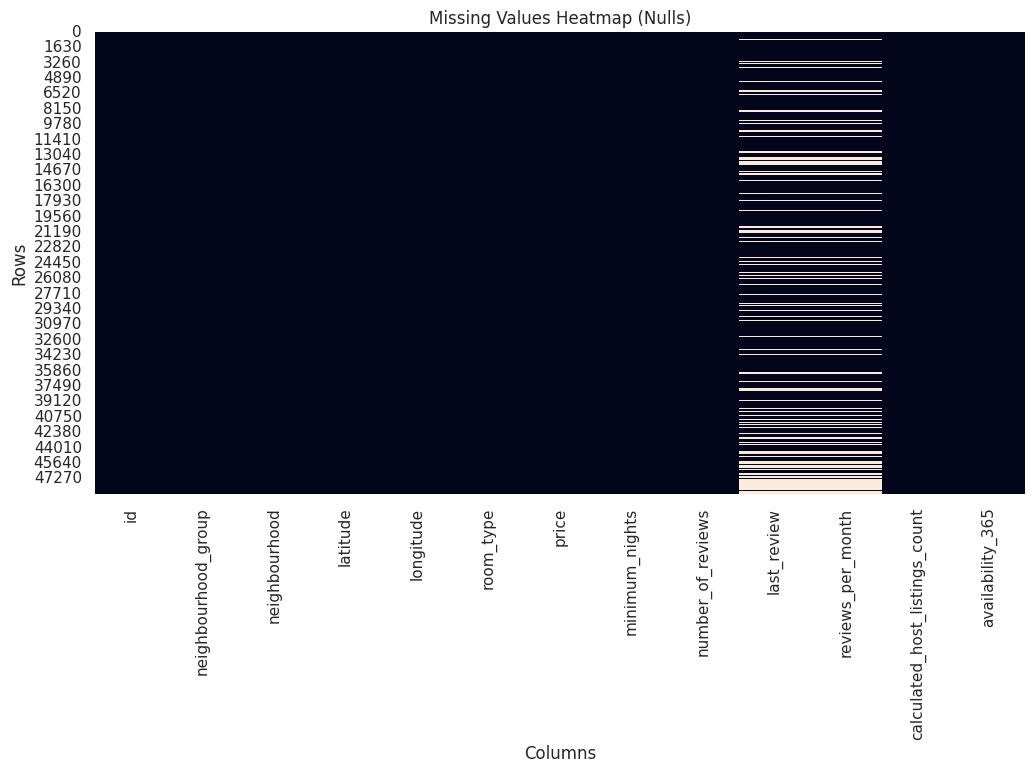

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap (Nulls)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

### 💡 Insight

**Missing values** are mainly concentrated in the **`last_review`** and **`reviews_per_month`** columns.

#🧩 ***Handling Missing Data***

### **`reviews_per_month`**
The column contains 20.56% missing values.  
These missing values correspond to listings with no reviews.  
Since a listing without reviews means having 0 reviews per month,
missing values were replaced with **0**.

### **`last_review`**
The column also contains 20.56% missing values.  
Missing values indicate listings with no review history.  
The column was converted to datetime format, and missing values were left as **NaN** to preserve their real meaning.

**Listings without reviews likely represent new or inactive properties.**

In [ ]:
print("Missing values before cleaning:")
print(df[["reviews_per_month", "last_review"]].isna().sum())

Missing values before cleaning:
reviews_per_month    10052
last_review          10052
dtype: int64


In [ ]:
# Handling reviews_per_month
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [ ]:
# Handling last_review
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

##🧠 **Feature Engineering**
**i.** A new binary classification feature (`has_review`) was created to indicate whether a listing has received reviews or not.

This feature helps to distinguish active listings from inactive ones, as reviews reflect real booking activity and user engagement.

In [ ]:
# Creating 'has_review' feature
df["has_review"] = df["last_review"].notna().astype(int)

In [ ]:
# --- After Cleaning (Check Missing Values) ---
print("Missing values after cleaning:")
print(df[["reviews_per_month", "last_review"]].isna().sum())

Missing values after cleaning:
reviews_per_month        0
last_review          10052
dtype: int64


#### **Alternative Approach: Filling `last_review` with the Minimum Date**

Missing values in `last_review` were filled with **the earliest available review date** in the dataset.

The idea behind this method is to preserve a valid datetime format while avoiding null values.

However, this approach may introduce bias, as it assumes that listings without reviews had very old review activity, which is not accurate.

In [ ]:
# Copy dataset
df_test = df.copy()

# datetime format
df_test["last_review"] = pd.to_datetime(df_test["last_review"], errors="coerce")

# Get minimum existing review date
min_date = df_test["last_review"].min()


# Fill missing values with the minimum date
df_test["last_review"] = df_test["last_review"].fillna(min_date)

# Check missing values after filling
print("Missing values after filling with minimum date:")
print(df_test["last_review"].isna().sum())

Missing values after filling with minimum date:
0


In [ ]:
df.columns

Index(['id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'has_review'],
      dtype='object')



---



---



# 📊 **Exploratory Data Analysis**

##🔢 **Numerical Analysis**

In [ ]:
num_cols = df.select_dtypes(include="number").columns[1:] #not include id
num_cols

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'has_review'],
      dtype='object')

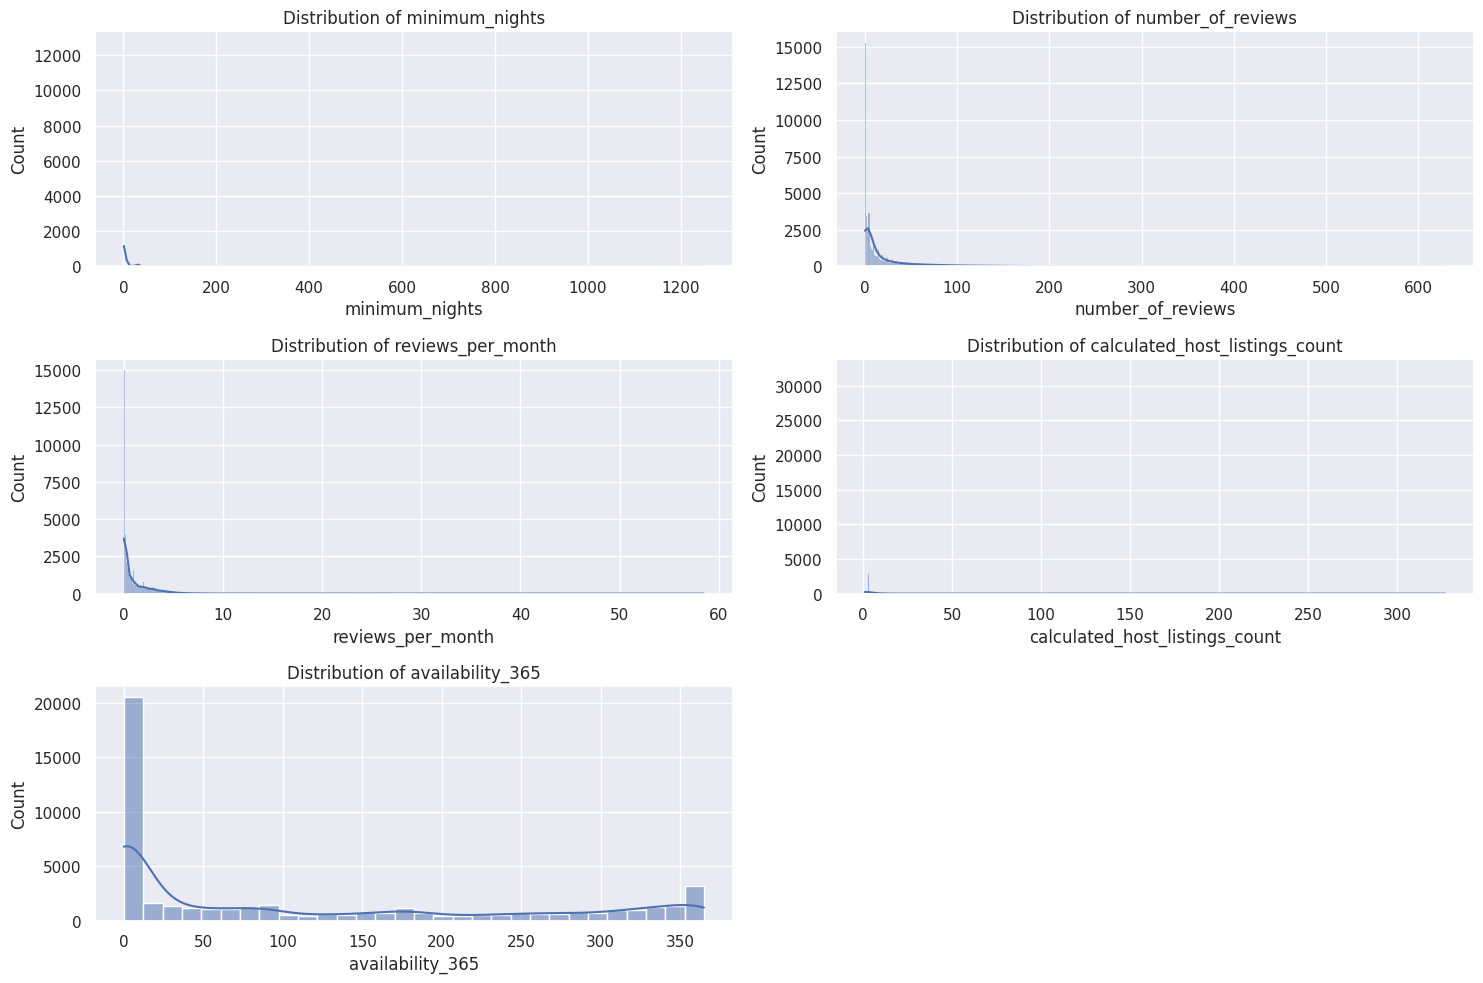

In [ ]:
cols = num_cols[3:8]
plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

##📈 **Univariate Analysis of Numerical Features**

The distributions of most numerical variables do not show clear symmetric patterns.

They are heavily right-skewed, where the majority are at lower values while a small number of extreme values extend the distribution.

The observed skewness supports the earlier decision to apply outlier treatment and scaling.

## 🏷️ **Categorical Variables Analysis**

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['neighbourhood_group', 'neighbourhood', 'room_type']

In [ ]:
for col in cat_cols:
    print(f'{col}: {df[col].nunique()}')

neighbourhood_group: 5
neighbourhood: 221
room_type: 3


In [ ]:
neighbourhood_group_pct = df.neighbourhood_group.value_counts(normalize = True)
neighbourhood_group_pct

,proportion
neighbourhood_group,
Manhattan,0.44
Brooklyn,0.41
Queens,0.12
Bronx,0.02
Staten Island,0.01


In [ ]:
neighbourhood_palette = {
    "Manhattan": "#FF5A5F",
    "Brooklyn": "#008489",
    "Queens": "#FFB400",
    "Bronx": "#7B61FF",
    "Staten Island": "#4CAF50"
}

In [ ]:
import plotly.express as px #Interactive visualization
px.pie(neighbourhood_group_pct, values=neighbourhood_group_pct.values, names=neighbourhood_group_pct.index, title='Neighbourhood Group', color=neighbourhood_palette)


In [ ]:
room_type_palette = {
    "Entire home/apt": "#FF5A5F",
    "Private room": "#008489",
    "Shared room": "#FFB400"
}

/tmp/ipykernel_763/3519101844.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




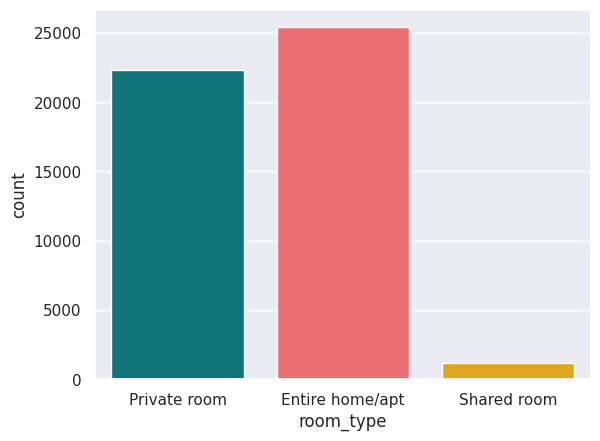

In [ ]:
sns.countplot(x='room_type', data=df, palette=room_type_palette);

### 💡 Insight
**Entire home/apartment** listings represent the largest proportion of accommodations, and then by **private rooms**, while **shared rooms** are relatively rare.

This suggests that users prefer more private accommodation options.

In [ ]:
top_10_neighbourhoods = df['neighbourhood'].value_counts().head(10)
top_10_neighbourhoods

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
Hell's Kitchen,1958
East Village,1853
Upper East Side,1798
Crown Heights,1564


/tmp/ipykernel_763/3092140592.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




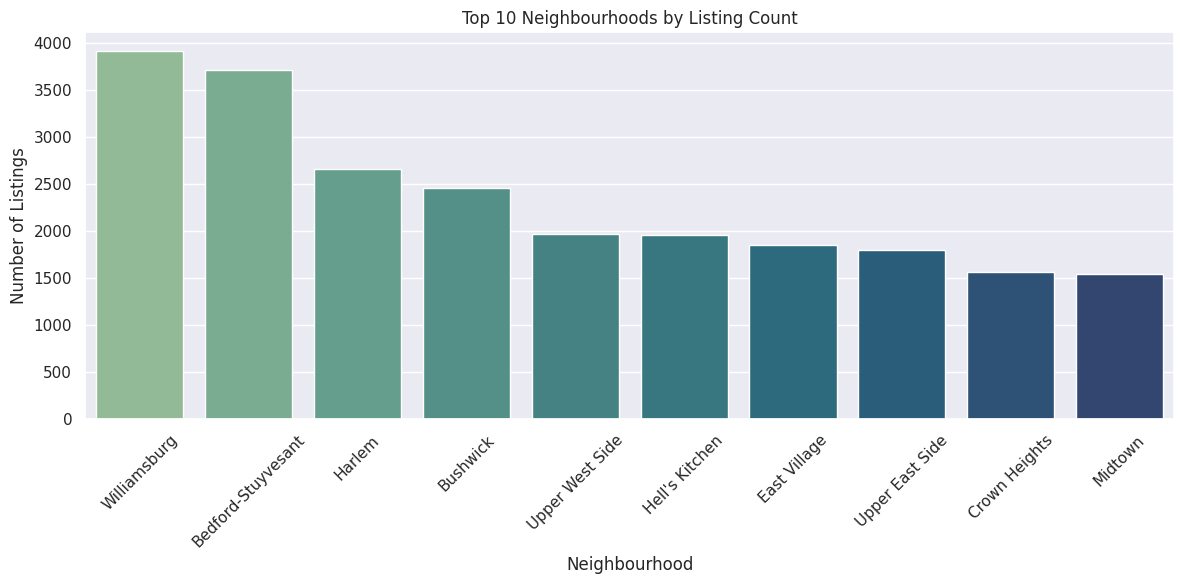

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_neighbourhoods.index, y=top_10_neighbourhoods.values, palette=sns.color_palette("crest", len(top_10_neighbourhoods)))
plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 💡 Insight

**Williamsburg**, **Bedford-Stuyvesant**, and **Harlem** have the highest listing counts, showing that Airbnb activity is concentrated in accessible and relatively affordable neighbourhoods with strong demand.

#⚠️ **Handling Outliers**

## Outlier Detection and Treatment

Based on the descriptive statistics `df.describe` and Distribution of numeric variables, several of them show extreme maximum values compared to their 75th percentile (Q3), indicating potential outliers.

The potential variables:
- **`price`**
- **`minimum_nights`**
- **`number_of_reviews`**
- **`reviews_per_month`**
- **`calculated_host_listings_count`**

***Outliers*** were detected using **boxplots** and the **IQR** method.

📊 **Checking Visually**

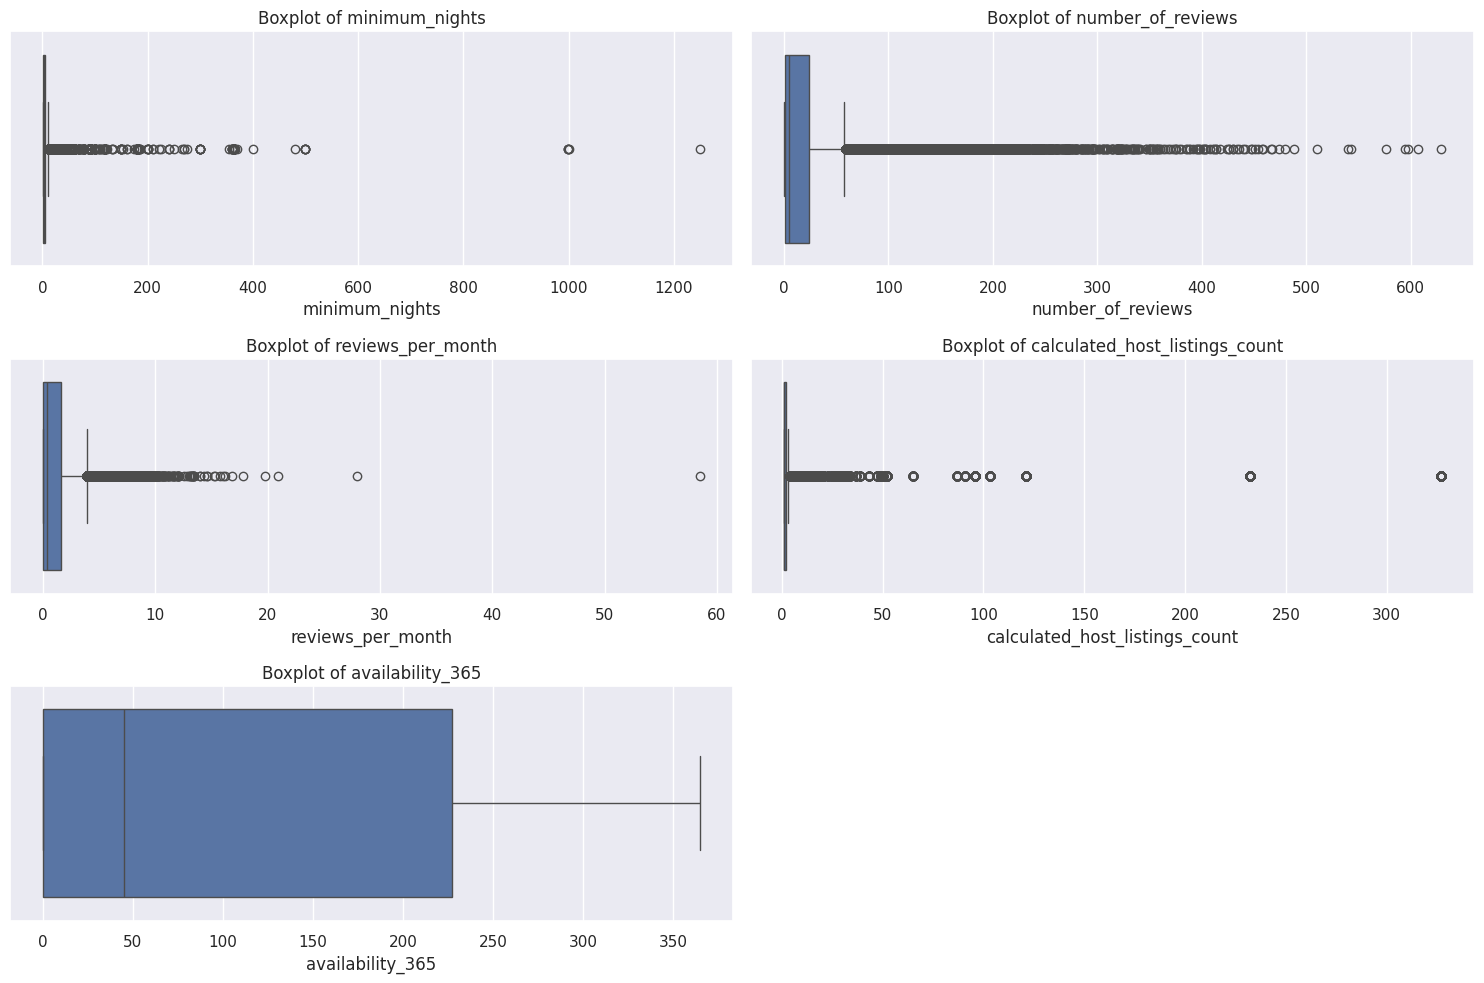

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

### 💡 Insight

Boxplots reveal the presence of extreme values, particularly in `price` and `minimum_nights`.
These outliers need the application of the IQR method to control outlier treatment.

📐**Checking Mathematically**

In [ ]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

*Try the IQR:*

In [ ]:
df_copy = df.copy()

In [ ]:
df_clean_outlier = remove_outliers_iqr(df_copy, "minimum_nights")

print("Rows after minimum_nights cleaning:", len(df_clean_outlier))

Rows after minimum_nights cleaning: 42288


In [ ]:
df.shape

(48895, 14)

**Many rows were deleted so try another way: *Clipping***




In [ ]:
def clip_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[column] = data[column].clip(lower, upper)
    return data

In [ ]:
for col in cols[:4]:
    df = clip_outliers_iqr(df, col)

print("Rows after clipping:", len(df))

Rows after clipping: 48895


Instead of removing all outliers, **clipping(winsorization)** was applied to preserve dataset size while limiting the influence of extreme values.

#🔗 **Feature Relationships**

***Neighbourhood Group and Price***

In [ ]:
df.groupby("neighbourhood_group")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,"1,091.00",87.50,106.71,0.00,45.00,65.00,99.00,"2,500.00"
Brooklyn,"20,104.00",124.38,186.87,0.00,60.00,90.00,150.00,"10,000.00"
Manhattan,"21,661.00",196.88,291.38,0.00,95.00,150.00,220.00,"10,000.00"
Queens,"5,666.00",99.52,167.10,10.00,50.00,75.00,110.00,"10,000.00"
Staten Island,373.00,114.81,277.62,13.00,50.00,75.00,110.00,"5,000.00"


/tmp/ipykernel_763/1597031887.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




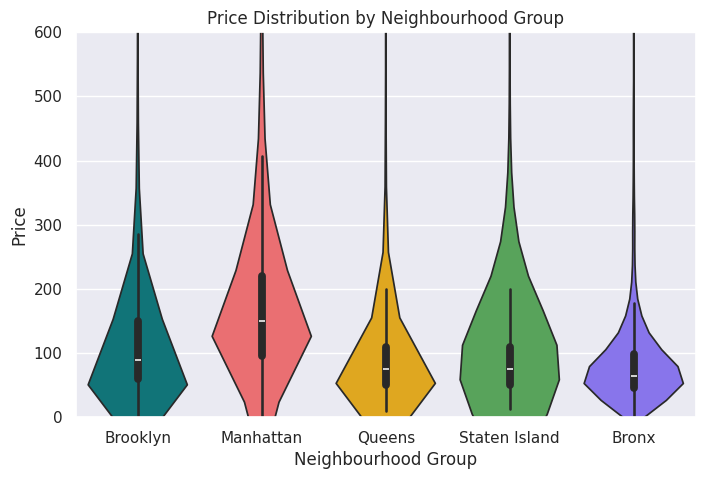

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x="neighbourhood_group", y="price", data=df, palette=neighbourhood_palette )
plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.ylim(0, 600)
plt.show()


### 💡 Insight

**Manhattan** exhibits the highest price distribution among neighbourhood groups, while **Queens** and the **Bronx** tend to have more affordable listings.

Most listings across all areas are concentrated in lower price ranges, with a few high-priced outliers extending the distribution.

***price by neighbourhood_group & room_type***

In [ ]:
df.groupby(['neighbourhood_group', 'room_type'])['price'].mean().sort_values(ascending=False)

neighbourhood_group  room_type      
Manhattan            Entire home/apt   249.24
Brooklyn             Entire home/apt   178.33
Staten Island        Entire home/apt   173.85
Queens               Entire home/apt   147.05
Bronx                Entire home/apt   127.51
Manhattan            Private room      116.78
                     Shared room        88.98
Brooklyn             Private room       76.50
Queens               Private room       71.76
                     Shared room        69.02
Bronx                Private room       66.79
Staten Island        Private room       62.29
Bronx                Shared room        59.80
Staten Island        Shared room        57.44
Brooklyn             Shared room        50.53
Name: price, dtype: float64

In [ ]:
neighbourhood_group_room = pd.pivot_table(df, index='neighbourhood_group', columns='room_type', values='price', aggfunc='mean')
neighbourhood_group_room

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,127.51,66.79,59.80
Brooklyn,178.33,76.50,50.53
Manhattan,249.24,116.78,88.98
Queens,147.05,71.76,69.02
Staten Island,173.85,62.29,57.44


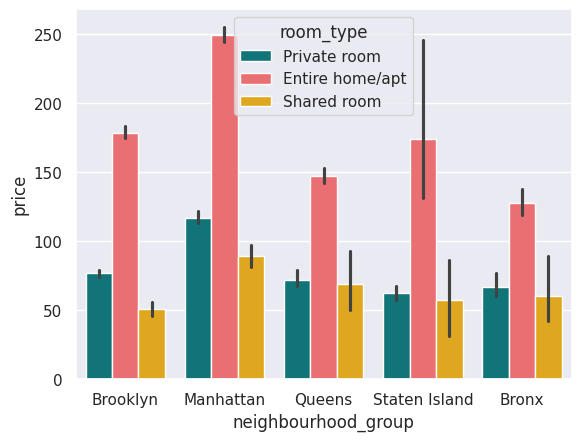

In [ ]:
sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data=df, palette=room_type_palette);

### 💡 Insight

**Manhattan** shows the highest average prices across most room types, and then **Brooklyn**.

**Entire homes** are consistently more expensive than private or shared rooms, highlighting the strong influence of location and accommodation type on pricing.

🗺 ***Geographical Distribution***

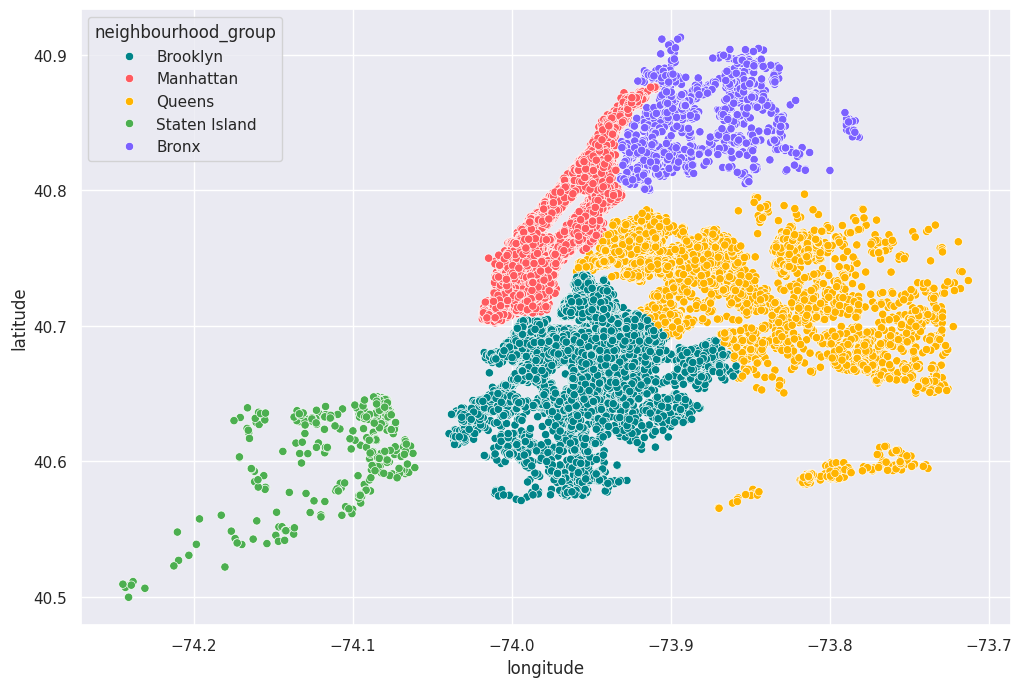

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='longitude', y='latitude', data=df, hue='neighbourhood_group', palette=neighbourhood_palette);

### 💡 Insight

The geographical scatter plot shows clear clustering of listings based on neighbourhood groups.
Most listings are concentrated in **Manhattan**, **Queens**, and **Brooklyn**, indicating higher Airbnb activity in these areas compared to other regions.

***Availability & Room type***

/tmp/ipykernel_763/3870120942.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='room_type', ylabel='availability_365'>

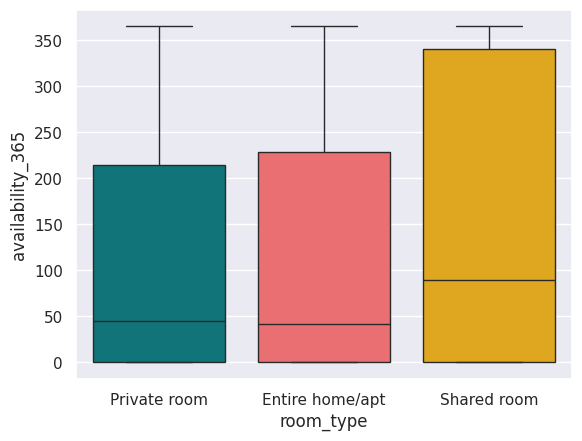

In [ ]:
sns.boxplot(x="room_type", y="availability_365", data=df, palette=room_type_palette)

### 💡 Insight

**Shared rooms** show higher availability compared to private rooms and entire homes.

This indicates lower demand for shared accommodations, while private and entire listings are booked more frequently, reducing their available days throughout the year.

***Price VS Room type***

/tmp/ipykernel_763/2201506901.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




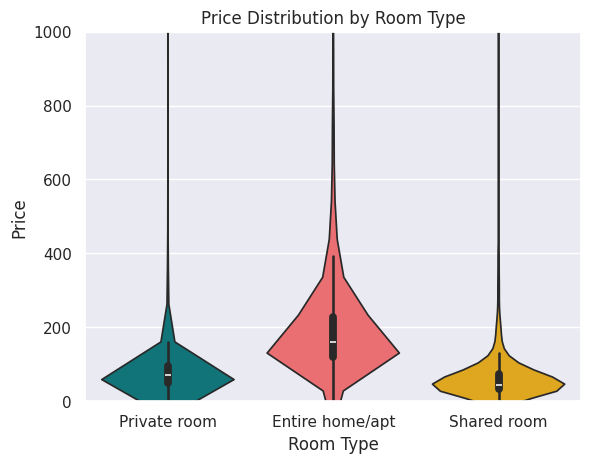

In [ ]:
sns.violinplot(x="room_type", y="price", data=df, palette=room_type_palette)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.ylim(0, 1000)
plt.show()


### 💡 Insight

 **Entire homes/apartments** show the highest price distribution, followed by **private rooms**, while **shared rooms** remain the most affordable option.

The majority of listings across all room types are concentrated in lower price ranges.

*Same thing*:

/tmp/ipykernel_763/867458004.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




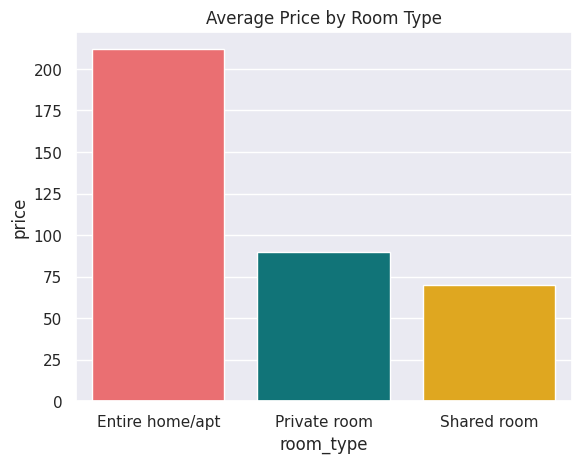

In [ ]:
avg_price = df.groupby("room_type")["price"].mean().reset_index()

sns.barplot(x="room_type", y="price", data=avg_price, palette=room_type_palette)
plt.title("Average Price by Room Type")
plt.show()

***Price vs Neighbourhood***

/tmp/ipykernel_763/3384031606.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 0, 'Average Price')

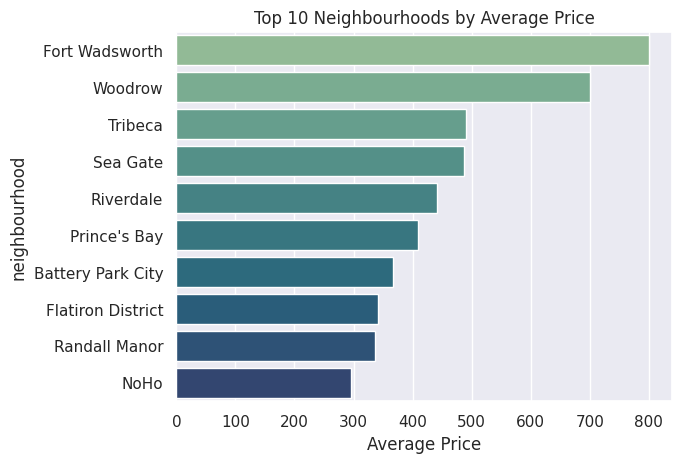

In [ ]:
top_neighbourhood_price = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_neighbourhood_price.values, y=top_neighbourhood_price.index, palette=sns.color_palette("crest", len(top_10_neighbourhoods)))
plt.title("Top 10 Neighbourhoods by Average Price")
plt.xlabel("Average Price")


### 💡 Insight

**Fort Wadsworth** and **Woodrow** have the highest average Airbnb prices among all neighbourhoods, indicating that listings in these areas are positioned as premium accommodations.

Other neighbourhoods such as **Tribeca** and **Sea Gate** also show relatively high prices, reflecting their desirability and potential demand.

***Number of Reviews VS Avalability_365***

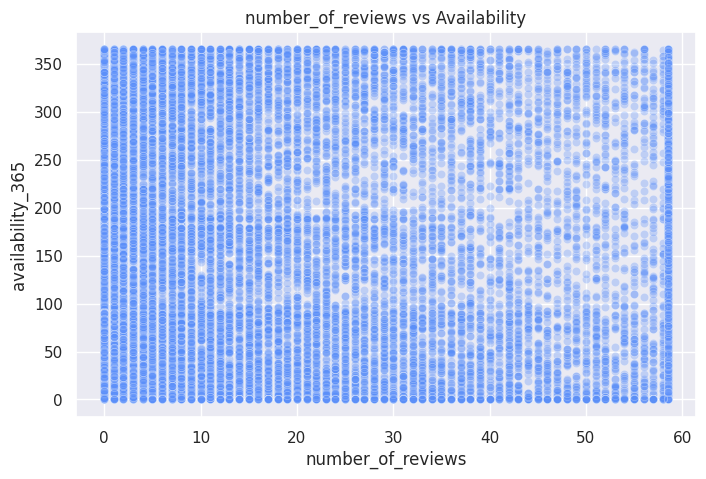

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="number_of_reviews", y="availability_365", data=df, alpha=0.3, color = "#5B8FF9")
plt.title("number_of_reviews vs Availability")
plt.show()

### 💡 Insight

**No strong relationship** appears between the number of `reviews` and listing `availability`.

***Reviews per month vs Price***

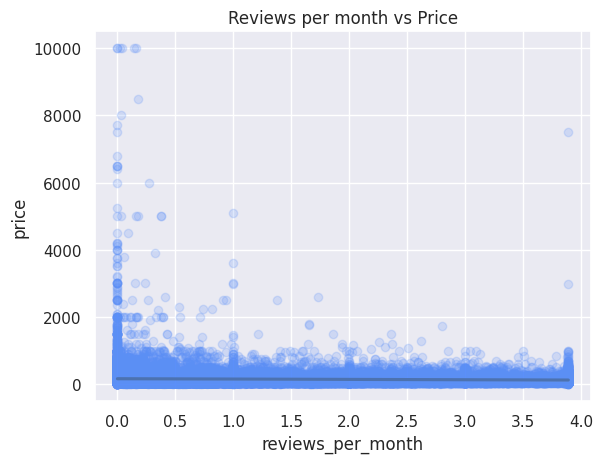

In [ ]:
sns.regplot(x="reviews_per_month", y="price", data=df, scatter_kws={"alpha":0.2, "color": "#5B8FF9"})
plt.title("Reviews per month vs Price")
plt.show()

***Price vs Availability***

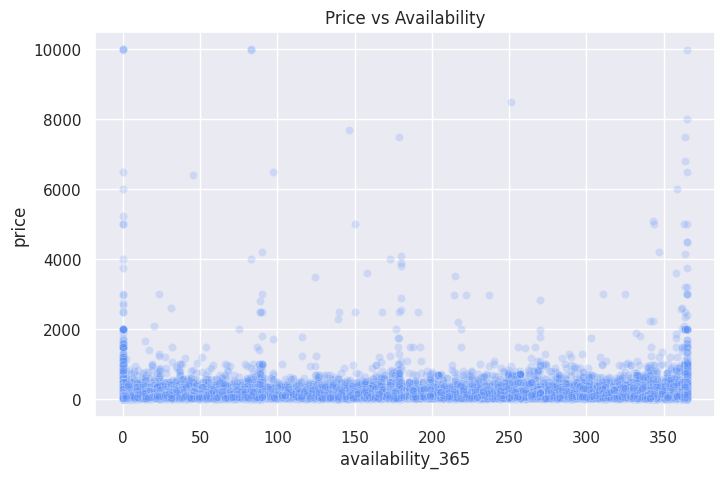

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="availability_365", y="price", data=df, alpha=0.2, color = "#5B8FF9")
plt.title("Price vs Availability")
plt.show()

### 💡 Insight

-  **No clear relationship**  was observed between `price` and `availability`, indicating that availability alone does not strongly influence pricing.

- **No clear relationship** was observed between `price` and `reviews per month`.

In [ ]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.00
availability_365,0.08
minimum_nights,0.03
latitude,0.03
id,0.01
calculated_host_listings_count,-0.02
reviews_per_month,-0.05
number_of_reviews,-0.06
has_review,-0.09
longitude,-0.15


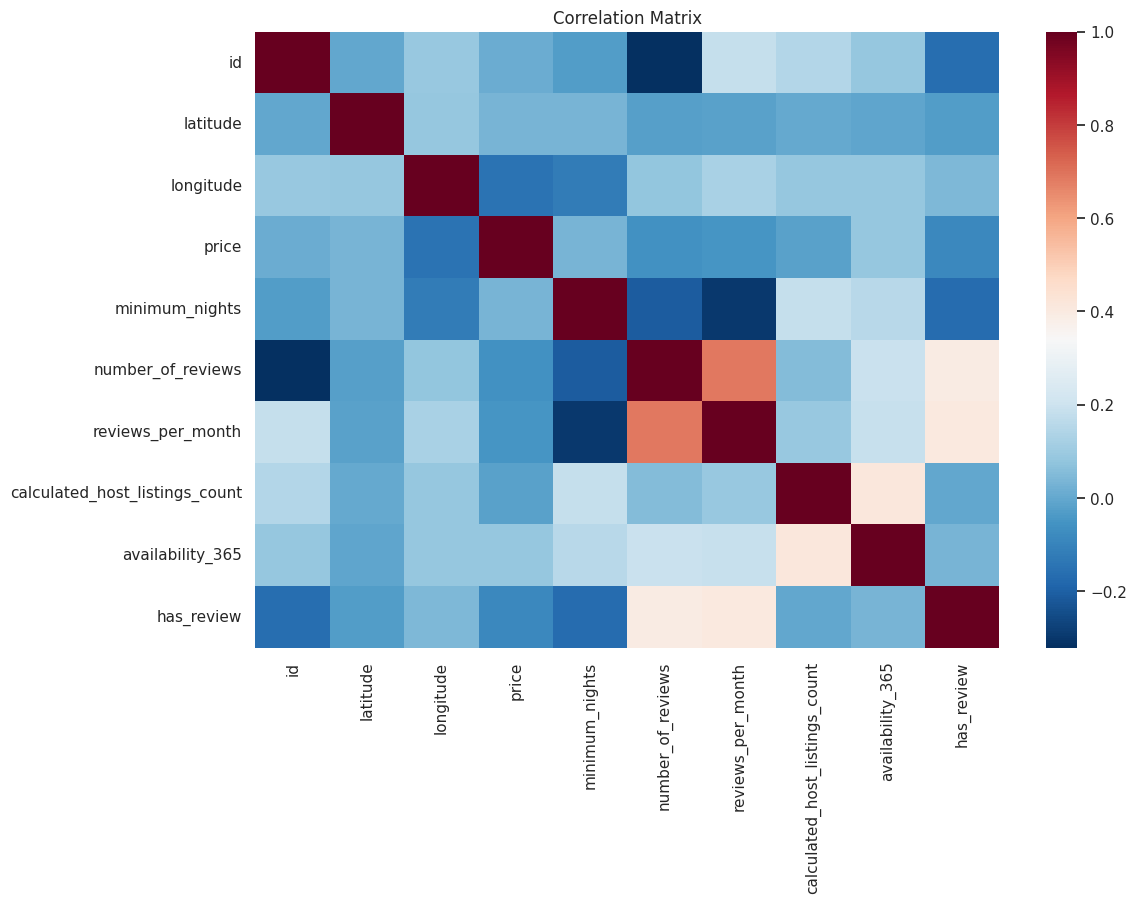

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="RdBu_r")
plt.title("Correlation Matrix")
plt.show()

### 💡 Insight

Most variables show weak correlations with price, while review-related variables demonstrate moderate relationships with each other.
This suggests that pricing is influenced by multiple factors rather than a single dominant variable.


---

# ⚙️ ***Feature Transformation***


---

 * ## 🔄 **Data Type Conversions**
  has been done on **`last_review`**
from *string* to    *datetime*.

In [ ]:
df.dtypes

,0
id,int64
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64
minimum_nights,int64
number_of_reviews,float64
last_review,datetime64[ns]


* ## 🧠 **Feature Engineering ii**

In [ ]:
df["review_year"] = df["last_review"].dt.year

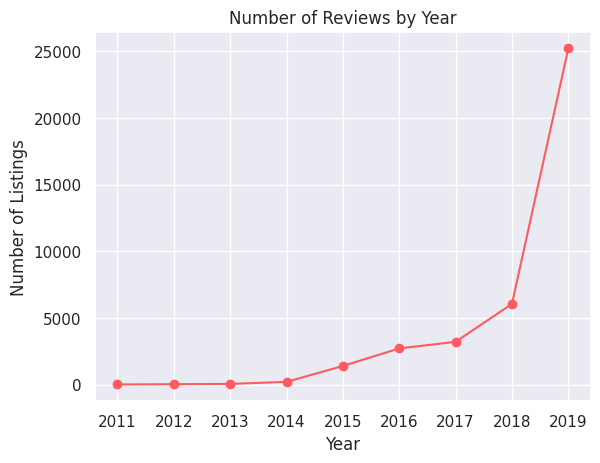

In [ ]:
review_counts = df["review_year"].value_counts().sort_index()

plt.plot(
    review_counts.index,
    review_counts.values,
    marker="o",
    color="#FF5A5F"
)
plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Listings")
plt.show()

### 💡 Insight

The number of reviews increases significantly in recent years, indicating growing platform activity and higher user engagement over time.
Older years contain fewer reviews, suggesting that most listings became active more recently.

In [ ]:
df.head()

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,review_year
0,2539,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9.00,2018-10-19,0.21,3.50,365,1,"2,018.00"
1,2595,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45.00,2019-05-21,0.38,2.00,355,1,"2,019.00"
2,3647,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0.00,NaT,0.00,1.00,365,0,NaN
3,3831,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,58.50,2019-07-05,3.89,1.00,194,1,"2,019.00"
4,5022,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9.00,2018-11-19,0.10,1.00,0,1,"2,018.00"



---

### 💾 **Saving Processed Dataset**

In [ ]:
df.to_csv("CleanedDatabeForPowerBI.csv", index=False)
print("Saved file: CleanedDatabeForPowerBI.csv")

Saved file: CleanedDatabeForPowerBI.csv


* ## 🔢 **Encoding Categorical Variables**

In [ ]:
df.select_dtypes(include="object").columns

Index(['neighbourhood_group', 'neighbourhood', 'room_type'], dtype='object')

In [ ]:
df = pd.get_dummies(df, columns=["neighbourhood_group","room_type"], drop_first=True)   # To avoid multicollinearity

In [ ]:
df['neighbourhood'].nunique()

221

The **`neighbourhood`** column contains a large number of unique categories.
One-hot encoding was not applied to avoid high dimensionality and sparsity.

***Log Transform after Price Distribution***

In [ ]:
df["log_price"] = np.log1p(df["price"])

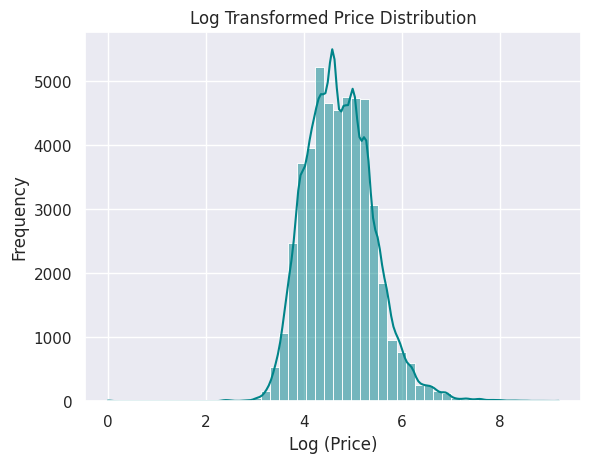

In [ ]:
sns.histplot(df["log_price"], kde=True, bins=50, color="#008489")
plt.title("Log Transformed Price Distribution")
plt.xlabel("Log (Price)")
plt.ylabel("Frequency")
plt.show()

**Log transformation** was applied to the price variable to reduce skewness and improve distribution.

* ## ⚖️ **Scaling**
***Min-Max*** scaling was applied to selected numerical variables to standardize feature ranges.

In [ ]:
scale_cols = [
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "calculated_host_listings_count"
]
for col in scale_cols:
    min_v = df[col].min()
    max_v = df[col].max()
    df[col] = (df[col] - min_v) / (max_v - min_v)

## 🧾   **Feature Engineering Summary**

* Two new features were created from the review information. The **has_review** feature is a binary variable indicating whether a listing has received at least one review. This feature helps distinguish between active listings and those without customer interaction, providing an indicator of listing engagement and potential demand.

* Additionally, a new temporal feature called **review_year** was derived from the *last_review* column. This feature captures the year of the most recent review and helps analyze review activity trends over time.


* Categorical variables were encoded to convert textual categories into numerical representations suitable for analysis.

* Selected numerical features were also scaled to reduce differences in magnitude between variables and improve compatibility with machine learning algorithms.

These transformations help the dataset capture meaningful behavioral patterns while ensuring that the data is structured and consistent for modeling purposes.

In [ ]:
df.to_csv("Cleaned Data.csv", index=False)
print("Saved file: Cleaned Data.csv")


Saved file: Cleaned Data.csv


##📑 **Dataset Summary**

After completing data cleaning, exploratory data analysis **(EDA)**, outlier treatment, and feature engineering, the Airbnb dataset has been successfully prepared for further analytical and predictive tasks.

Key preparation steps included:
* Handling missing values using appropriate imputation strategies.
* Detecting and treating outliers using the IQR method and Clipping.
* Encoding categorical variables.
* Creating derived features to capture listing behavior.
* Scaling numerical variables where necessary.

The final processed dataset was saved as **Cleaned Data**, ensuring a clean, structured, and reproducible dataset ready for advanced analysis, visualization, and machine learning modeling.
---


#📈**Insights & Conclusion**

Through exploratory data analysis of the New York City Airbnb dataset, several patterns emerged regarding pricing behavior, location influence, room types, and booking activity across the platform.

* **Price Distribution**

Most Airbnb listings fall within a moderate price range, typically between $50 and $300 per night. A small number of listings exhibit extremely high prices, representing luxury or premium properties, which were treated as outliers during the analysis.

* **Neighbourhood Activity**

Airbnb listings are highly concentrated in Manhattan and Brooklyn, indicating that these areas represent the most active rental markets in New York City. Other boroughs such as Queens, Staten Island, and the Bronx show comparatively lower listing density.

* **Room Type Patterns**

Entire homes/apartments dominate the Airbnb market and generally command higher prices due to increased privacy and space.
Private rooms provide mid-range accommodation options, while shared rooms remain the least common and most affordable listing type.

* **Location Impact on Price**

Location plays a significant role in determining listing prices. Certain neighbourhoods, particularly those in Manhattan, show considerably higher average prices, suggesting strong demand and premium property positioning.

* **Availability and Booking Behavior**

Listing availability varies significantly across properties. However, availability does not show a strong correlation with price, suggesting that host strategies and booking patterns differ widely across listings.

* **Customer Engagement and Reviews**

Listings with a higher number of reviews often indicate greater booking activity and customer engagement. However, premium listings do not always receive a high number of reviews. Missing review dates typically correspond to listings that have not yet received bookings.


---

# 🔑 **Key Findings**

1. Manhattan and Brooklyn dominate the Airbnb market in terms of listing activity and demand.


2. Entire homes/apartments are the most expensive listing type, while shared rooms remain the most affordable.


3. Price does not strongly correlate with availability, indicating diverse hosting strategies.


4. More affordable listings tend to accumulate more reviews, suggesting stronger demand for mid-range accommodations.


5. Airbnb activity has increased over time, reflecting growing platform adoption and user engagement.




---

# 📊 **Conclusion**

• The analysis highlights clear relationships between location, room type, pricing, and listing activity within the New York City Airbnb market. Premium neighbourhoods and entire-home listings tend to command higher prices, while more affordable listings attract greater booking activity and reviews.

• These findings provide valuable insights for hosts, travelers, and analysts, helping them better understand market dynamics and optimize pricing or listing strategies.

• Overall, this exploratory data analysis establishes a strong analytical foundation for future predictive modeling, pricing optimization, and data-driven decision making in the Airbnb marketplace.


---

**This analysis demonstrates how exploratory data analysis can reveal important market patterns and support data-driven decision making in the short-term rental industry.**